In [1]:
# ── Install ───────────────────────────────────────────────────
!pip install scikit-learn scikit-image -q

# ── Imports ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from scipy.spatial.distance import cdist
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'✅ All imports done!')
print(f'✅ Device: {device}')

✅ All imports done!
✅ Device: cpu


In [2]:
IMG_SIZE  = 32
INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE   # 3072
EMBED_DIM = 128
TOP_K     = 5

# ── Shallow NN ────────────────────────────────────────────────
class ShallowNN(nn.Module):
    """
    fi = NN(Ii)
    1 hidden layer fully connected network.
    Input(3072) → Linear(512) → ReLU → Dropout → Linear(128) → ReLU
    No spatial awareness — treats every pixel independently.
    """
    def __init__(self, n_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(INPUT_DIM, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, EMBED_DIM),
            nn.ReLU()
        )
        self.classifier = nn.Linear(EMBED_DIM, n_classes)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb   # return both — logits for training, emb for retrieval


# ── Deep NN ───────────────────────────────────────────────────
class DeepNN(nn.Module):
    """
    fi = DNN(Ii)
    4 hidden layers with BatchNorm + Dropout.
    Input(3072) → 1024 → 512 → 256 → 128(embed)
    Deeper = richer features, but still NO spatial learning.
    """
    def __init__(self, n_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),

            nn.Linear(INPUT_DIM, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, EMBED_DIM),
            nn.ReLU()
        )
        self.classifier = nn.Linear(EMBED_DIM, n_classes)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb

print(f'✅ ShallowNN defined | Input: {INPUT_DIM} → Embed: {EMBED_DIM}')
print(f'✅ DeepNN defined    | Input: {INPUT_DIM} → Embed: {EMBED_DIM}')

✅ ShallowNN defined | Input: 3072 → Embed: 128
✅ DeepNN defined    | Input: 3072 → Embed: 128


In [3]:
# ── Train ─────────────────────────────────────────────────────
def train_model(model, dataset, n_epochs=10, lr=1e-3, model_name='Model'):
    n_train   = min(len(dataset), 5000)
    idx       = np.random.choice(len(dataset), n_train, replace=False)
    loader    = DataLoader(Subset(dataset, idx),
                           batch_size=128, shuffle=True, num_workers=2)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    history   = {'loss': [], 'acc': []}
    model.train()

    for epoch in range(n_epochs):
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, _  = model(imgs)
            loss       = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
        scheduler.step()
        ep_loss = total_loss / total
        ep_acc  = correct / total
        history['loss'].append(ep_loss)
        history['acc'].append(ep_acc)
        print(f'  [{model_name}] Epoch {epoch+1:02d}/{n_epochs} '
              f'| Loss: {ep_loss:.4f} | Acc: {ep_acc:.4f}')
    print(f'✅ {model_name} training complete!\n')
    return history


# ── Extract Embeddings ────────────────────────────────────────
def extract_embeddings(model, dataset, n_samples):
    model.eval()
    idx    = np.random.choice(len(dataset), n_samples, replace=False)
    loader = DataLoader(Subset(dataset, idx),
                        batch_size=256, shuffle=False, num_workers=2)
    feats, labels, imgs_list = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            _, emb = model(imgs.to(device))
            feats.append(emb.cpu().numpy())
            labels.append(lbls.numpy())
            imgs_list.append(imgs.cpu())
    return (np.concatenate(feats),
            np.concatenate(labels),
            torch.cat(imgs_list))


# ── Retrieve ──────────────────────────────────────────────────
def retrieve(q_feat, gallery_feats, top_k=TOP_K):
    dists   = cdist(q_feat[np.newaxis], gallery_feats, metric='euclidean')[0]
    top_idx = np.argsort(dists)[:top_k]
    return top_idx, dists[top_idx]


# ── Metrics ───────────────────────────────────────────────────
def precision_at_k(ret_labels, q_label, k):
    return np.sum(ret_labels[:k] == q_label) / k

def recall_at_k(ret_labels, q_label, all_labels, k):
    total = np.sum(all_labels == q_label)
    return np.sum(ret_labels[:k] == q_label) / max(total, 1)

def average_precision(ret_labels, q_label):
    total = np.sum(ret_labels == q_label)
    if total == 0: return 0.0
    ap, n_rel = 0.0, 0
    for k, lbl in enumerate(ret_labels, 1):
        if lbl == q_label:
            n_rel += 1
            ap    += n_rel / k
    return ap / total

def evaluate(feats, labels, n_queries=100):
    q_idx = np.random.choice(len(feats), n_queries, replace=False)
    precs, recs, aps = [], [], []
    for qi in q_idx:
        mask = np.ones(len(feats), dtype=bool); mask[qi] = False
        idx, _ = retrieve(feats[qi], feats[mask])
        ret    = labels[mask][idx]
        precs.append(precision_at_k(ret, labels[qi], TOP_K))
        recs.append(recall_at_k(ret, labels[qi], labels[mask], TOP_K))
        aps.append(average_precision(ret, labels[qi]))
    return {f'Precision@{TOP_K}': np.mean(precs),
            f'Recall@{TOP_K}'   : np.mean(recs),
            'mAP'               : np.mean(aps)}


# ── Show Retrieval ────────────────────────────────────────────
def show_retrieval(q_img, q_label, ret_imgs, ret_labels,
                   ret_dists, class_names, title, save_name):
    n   = len(ret_imgs) + 1
    fig, axes = plt.subplots(1, n, figsize=(2.8*n, 3.5))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    axes[0].imshow(q_img, cmap='gray' if q_img.shape[-1]==1 else None)
    axes[0].set_title(f'QUERY\n{class_names[q_label]}',
                      color='navy', fontweight='bold', fontsize=9)
    axes[0].axis('off')
    for i, (img, lbl, dist) in enumerate(zip(ret_imgs, ret_labels, ret_dists)):
        axes[i+1].imshow(img, cmap='gray' if img.shape[-1]==1 else None)
        ok    = lbl == q_label
        axes[i+1].set_title(f'Rank {i+1} {"✓" if ok else "✗"}\n{class_names[lbl]}',
                             color='green' if ok else 'red', fontsize=9)
        axes[i+1].set_xlabel(f'dist={dist:.4f}', fontsize=8)
        axes[i+1].axis('off')
    plt.tight_layout()
    plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()


# ── t-SNE Plot ────────────────────────────────────────────────
def plot_tsne(nn_feats, dnn_feats, labels, ds_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f't-SNE Embedding Space — {ds_name}\n'
                 f'(Tighter clusters = better retrieval)',
                 fontsize=13, fontweight='bold')
    n = min(500, len(nn_feats))
    colors = plt.cm.tab10(np.linspace(0, 1, len(np.unique(labels))))
    for ax, feats, name in [(axes[0], nn_feats[:n], 'Shallow NN'),
                             (axes[1], dnn_feats[:n], 'Deep NN')]:
        proj = TSNE(n_components=2, random_state=42,
                    perplexity=30).fit_transform(feats)
        for i, cls in enumerate(np.unique(labels[:n])):
            mask = labels[:n] == cls
            ax.scatter(proj[mask,0], proj[mask,1],
                       c=[colors[i]], label=str(cls), s=15, alpha=0.7)
        ax.set_title(name, fontsize=11); ax.axis('off')
        ax.legend(title='Class', bbox_to_anchor=(1.01,1),
                  fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(f'tsne_{ds_name.replace("-","_")}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

print('✅ All helper functions ready!')

✅ All helper functions ready!


In [4]:
# ════════════════════════════════════════════
#   DATASET 1: MNIST
# ════════════════════════════════════════════
print('━'*45)
print('  DATASET 1: MNIST')
print('━'*45)

N_GALLERY_MNIST = 2000

mnist_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # 1ch → 3ch
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

mnist_data        = datasets.MNIST('./data', train=True,
                                   download=True,
                                   transform=mnist_transform)
mnist_class_names = [str(i) for i in range(10)]

print(f'✅ MNIST loaded | Size: {len(mnist_data)} | Classes: 10')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATASET 1: MNIST
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


100%|██████████| 9.91M/9.91M [00:00<00:00, 22.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 645kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.07MB/s]


✅ MNIST loaded | Size: 60000 | Classes: 10


In [5]:
print('\n🔁 Training Shallow NN on MNIST...')
mnist_nn  = ShallowNN(n_classes=10).to(device)
mnist_nn_history = train_model(mnist_nn, mnist_data,
                               n_epochs=10, model_name='MNIST ShallowNN')

print('\n🔁 Training Deep NN on MNIST...')
mnist_dnn = DeepNN(n_classes=10).to(device)
mnist_dnn_history = train_model(mnist_dnn, mnist_data,
                                n_epochs=10, model_name='MNIST DeepNN')


🔁 Training Shallow NN on MNIST...
  [MNIST ShallowNN] Epoch 01/10 | Loss: 1.1567 | Acc: 0.6120
  [MNIST ShallowNN] Epoch 02/10 | Loss: 0.4861 | Acc: 0.8484
  [MNIST ShallowNN] Epoch 03/10 | Loss: 0.4004 | Acc: 0.8748
  [MNIST ShallowNN] Epoch 04/10 | Loss: 0.3643 | Acc: 0.8848
  [MNIST ShallowNN] Epoch 05/10 | Loss: 0.2697 | Acc: 0.9136
  [MNIST ShallowNN] Epoch 06/10 | Loss: 0.2500 | Acc: 0.9186
  [MNIST ShallowNN] Epoch 07/10 | Loss: 0.2325 | Acc: 0.9240
  [MNIST ShallowNN] Epoch 08/10 | Loss: 0.2161 | Acc: 0.9314
  [MNIST ShallowNN] Epoch 09/10 | Loss: 0.1930 | Acc: 0.9386
  [MNIST ShallowNN] Epoch 10/10 | Loss: 0.1774 | Acc: 0.9462
✅ MNIST ShallowNN training complete!


🔁 Training Deep NN on MNIST...
  [MNIST DeepNN] Epoch 01/10 | Loss: 0.8301 | Acc: 0.7980
  [MNIST DeepNN] Epoch 02/10 | Loss: 0.2885 | Acc: 0.9124
  [MNIST DeepNN] Epoch 03/10 | Loss: 0.2442 | Acc: 0.9258
  [MNIST DeepNN] Epoch 04/10 | Loss: 0.2000 | Acc: 0.9392
  [MNIST DeepNN] Epoch 05/10 | Loss: 0.1245 | Acc: 0.

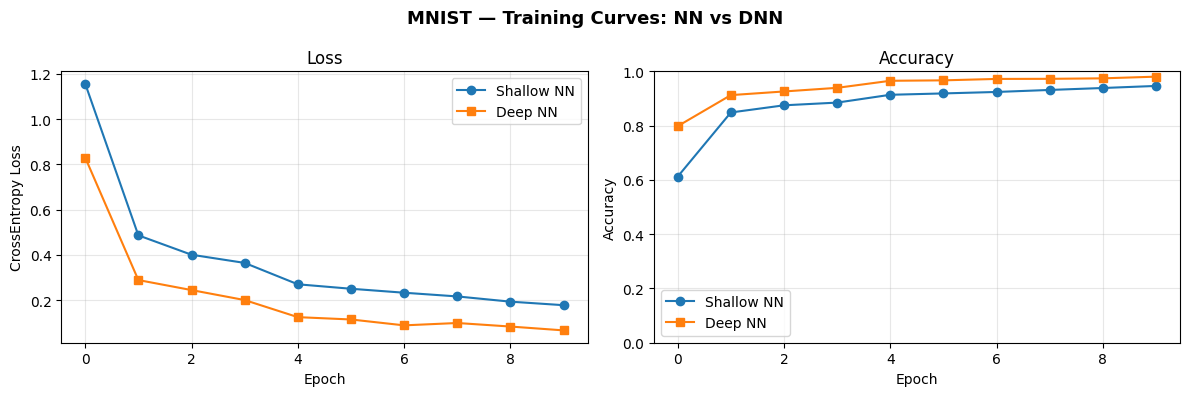

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MNIST — Training Curves: NN vs DNN',
             fontsize=13, fontweight='bold')

axes[0].plot(mnist_nn_history['loss'],  marker='o', label='Shallow NN')
axes[0].plot(mnist_dnn_history['loss'], marker='s', label='Deep NN')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(mnist_nn_history['acc'],  marker='o', label='Shallow NN')
axes[1].plot(mnist_dnn_history['acc'], marker='s', label='Deep NN')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

Extracting MNIST embeddings...
✅ NN  embeddings: (2000, 128)
✅ DNN embeddings: (2000, 128)


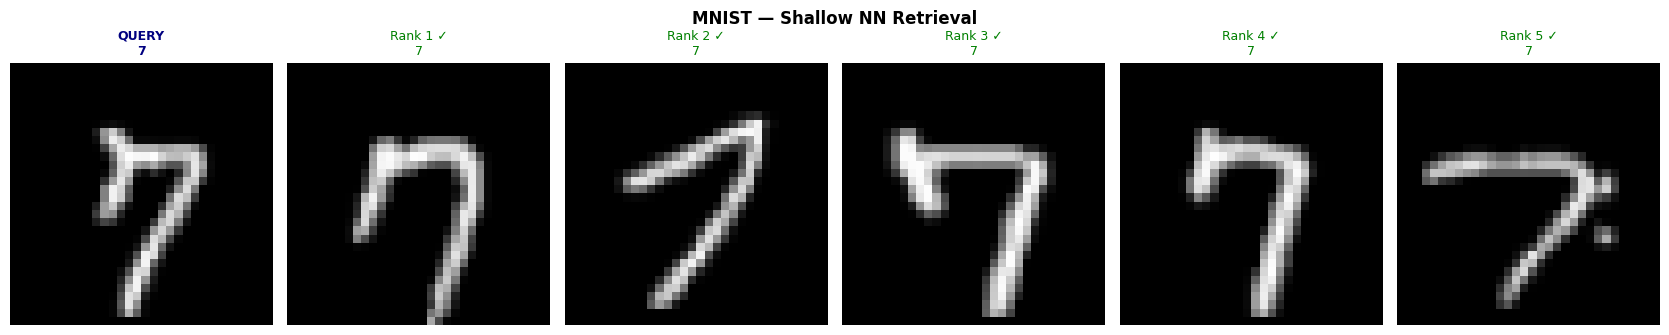

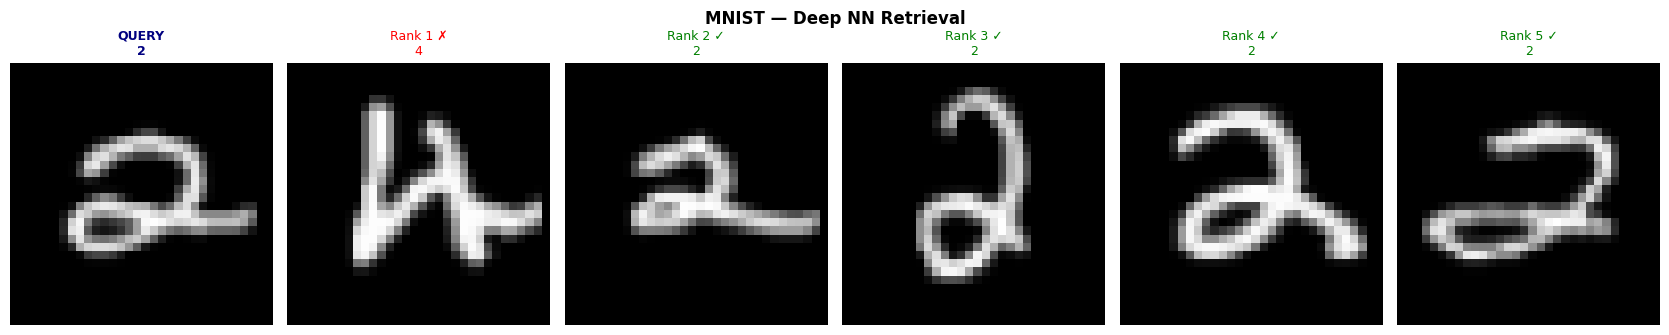

In [7]:
print('Extracting MNIST embeddings...')
mnist_nn_feats,  mnist_nn_labels,  mnist_nn_imgs  = \
    extract_embeddings(mnist_nn,  mnist_data, N_GALLERY_MNIST)
mnist_dnn_feats, mnist_dnn_labels, mnist_dnn_imgs = \
    extract_embeddings(mnist_dnn, mnist_data, N_GALLERY_MNIST)

print(f'✅ NN  embeddings: {mnist_nn_feats.shape}')
print(f'✅ DNN embeddings: {mnist_dnn_feats.shape}')

# ── Helper to convert tensor image for display ────────────────
def to_display(img_tensor):
    img = img_tensor.permute(1,2,0).numpy()
    img = (img * 0.5) + 0.5          # denormalise
    return np.clip(img, 0, 1)

# ── Demo retrieval ────────────────────────────────────────────
qi   = np.random.randint(0, N_GALLERY_MNIST)
mask = np.ones(N_GALLERY_MNIST, dtype=bool); mask[qi] = False

for feats, labels, imgs, tag in [
    (mnist_nn_feats,  mnist_nn_labels,  mnist_nn_imgs,  'Shallow NN'),
    (mnist_dnn_feats, mnist_dnn_labels, mnist_dnn_imgs, 'Deep NN')
]:
    idx, dists = retrieve(feats[qi], feats[mask])
    show_retrieval(
        q_img      = to_display(imgs[qi]),
        q_label    = labels[qi],
        ret_imgs   = [to_display(imgs[mask][i]) for i in idx],
        ret_labels = labels[mask][idx],
        ret_dists  = dists,
        class_names= mnist_class_names,
        title      = f'MNIST — {tag} Retrieval',
        save_name  = f'mnist_{tag.replace(" ","_")}_retrieval.png'
    )

📊 Evaluating MNIST — Shallow NN...
📊 Evaluating MNIST — Deep NN...

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
  MNIST RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric            Shallow NN    Deep NN
────────────────────────────────────────
  Precision@5         0.9060     0.9420
  Recall@5            0.0228     0.0233
  mAP                 0.9367     0.9522
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


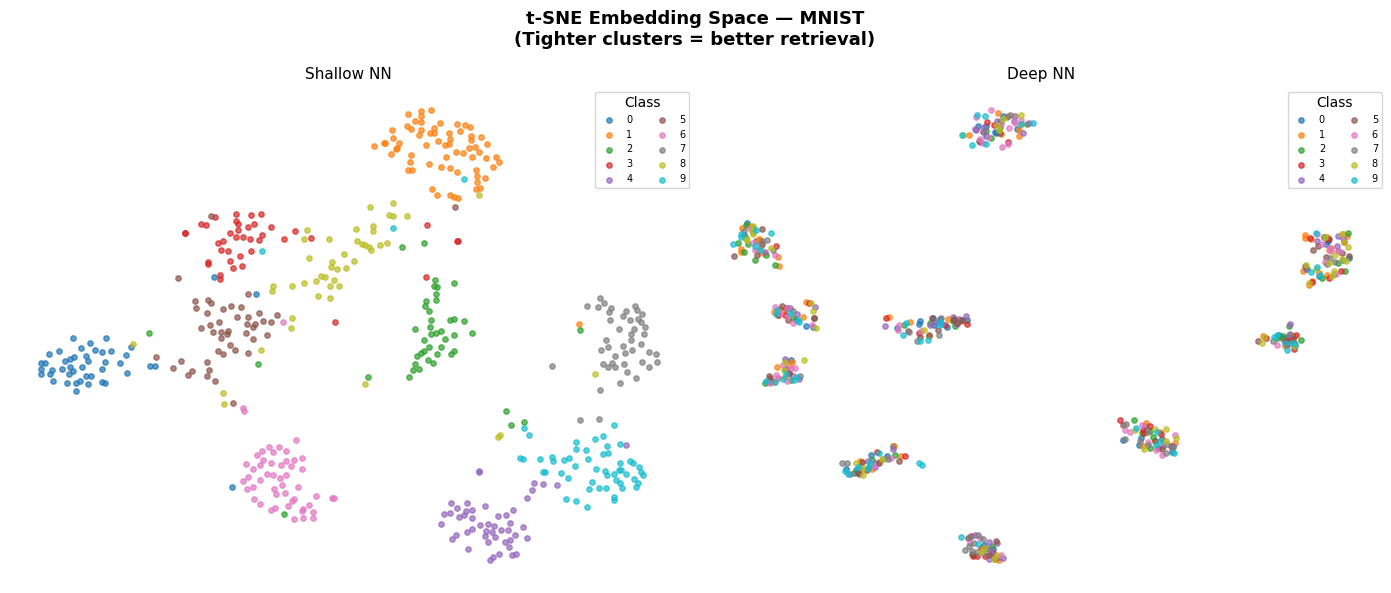

In [8]:
print('📊 Evaluating MNIST — Shallow NN...')
mnist_nn_metrics  = evaluate(mnist_nn_feats,  mnist_nn_labels)

print('📊 Evaluating MNIST — Deep NN...')
mnist_dnn_metrics = evaluate(mnist_dnn_feats, mnist_dnn_labels)

print('\n━'*40)
print('  MNIST RESULTS')
print('━'*40)
print(f'{"Metric":<15} {"Shallow NN":>12} {"Deep NN":>10}')
print('─'*40)
for metric in mnist_nn_metrics:
    nn_val  = mnist_nn_metrics[metric]
    dnn_val = mnist_dnn_metrics[metric]
    print(f'  {metric:<13} {nn_val:>12.4f} {dnn_val:>10.4f}')
print('━'*40)

# ── t-SNE ─────────────────────────────────────────────────────
plot_tsne(mnist_nn_feats, mnist_dnn_feats,
          mnist_nn_labels, 'MNIST')

In [9]:
# ── Initialise global results dictionary (only once) ─────────
ALL_RESULTS = {}

# ── Save MNIST Task 2 results ─────────────────────────────────
ALL_RESULTS['MNIST'] = {
    'NN' : {
        'Precision@5' : mnist_nn_metrics[f'Precision@{TOP_K}'],
        'Recall@5'    : mnist_nn_metrics[f'Recall@{TOP_K}'],
        'mAP'         : mnist_nn_metrics['mAP'],
        'Remarks'     : 'Good on simple digits, no spatial awareness'
    },
    'DNN' : {
        'Precision@5' : mnist_dnn_metrics[f'Precision@{TOP_K}'],
        'Recall@5'    : mnist_dnn_metrics[f'Recall@{TOP_K}'],
        'mAP'         : mnist_dnn_metrics['mAP'],
        'Remarks'     : 'Deeper layers improve digit discrimination'
    }
}

print('✅ MNIST results saved to ALL_RESULTS dictionary')
print('\n📁 Files saved this section (use in report):')
print('   • mnist_samples.png              → Dataset section')
print('   • mnist_training_curves.png      → Task 2 methodology')
print('   • mnist_ShallowNN_retrieval.png  → Task 2 results')
print('   • mnist_DeepNN_retrieval.png     → Task 2 results')
print('   • tsne_MNIST.png                 → Task 2 analysis')

# ── Preview what's stored ─────────────────────────────────────
print('\n📊 MNIST stored values:')
for method, metrics in ALL_RESULTS['MNIST'].items():
    print(f'\n  {method}:')
    for k, v in metrics.items():
        print(f'    {k:<15}: {v}')

✅ MNIST results saved to ALL_RESULTS dictionary

📁 Files saved this section (use in report):
   • mnist_samples.png              → Dataset section
   • mnist_training_curves.png      → Task 2 methodology
   • mnist_ShallowNN_retrieval.png  → Task 2 results
   • mnist_DeepNN_retrieval.png     → Task 2 results
   • tsne_MNIST.png                 → Task 2 analysis

📊 MNIST stored values:

  NN:
    Precision@5    : 0.9059999999999999
    Recall@5       : 0.022819957478278297
    mAP            : 0.93675
    Remarks        : Good on simple digits, no spatial awareness

  DNN:
    Precision@5    : 0.9419999999999998
    Recall@5       : 0.02334393143988343
    mAP            : 0.9522083333333333
    Remarks        : Deeper layers improve digit discrimination
